# SVM Classification — Student Dropout & Academic Success

**Dataset:** Predict Students' Dropout and Academic Success  
**Source:** https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success  
**Size:** 4,424 students | 36 features | 3 target classes (Dropout, Enrolled, Graduate)  
**Features include:** Demographics, application details, 1st & 2nd semester academic performance, socioeconomic indicators (GDP, unemployment, inflation)

In [36]:
!pip install ucimlrepo imbalanced-learn --quiet
from ucimlrepo import fetch_ucirepo
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')
import pkg_resources

packages = [
    "numpy", "pandas", "scikit-learn", "matplotlib",
    "seaborn", "imbalanced-learn", "ucimlrepo"
]

for p in packages:
    try:
        print(f"{p}: {pkg_resources.get_distribution(p).version}")
    except:
        print(f"{p}: not installed")

numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
imbalanced-learn: 0.14.1
ucimlrepo: 0.0.7


Shape: (4424, 36)  |  Missing values: 0

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


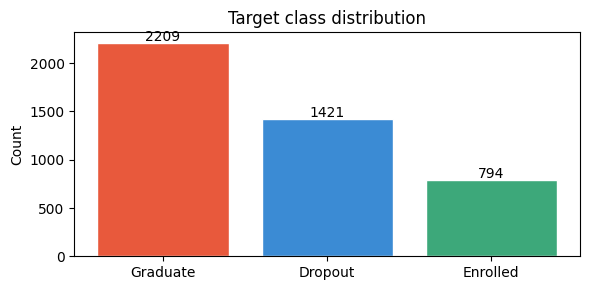

In [35]:
dataset = fetch_ucirepo(id=697)
X, y = dataset.data.features, dataset.data.targets

print(f'Shape: {X.shape}  |  Missing values: {X.isnull().sum().sum()}')
print('\nTarget distribution:')
print(y['Target'].value_counts().to_string())

counts = y['Target'].value_counts()
plt.figure(figsize=(6, 3))
bars = plt.bar(counts.index, counts.values,
               color=['#E8593C','#3B8BD4','#3DA87A'], edgecolor='white')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+20,
             str(int(b.get_height())), ha='center', fontsize=10)
plt.title('Target class distribution')
plt.ylabel('Count')
plt.tight_layout(); plt.show()

In [17]:
# Impute
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(X)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y['Target'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Feature selection
sel = VarianceThreshold(threshold=0.01)
X_sel = sel.fit_transform(X_imp)
print(f'Features: {X_imp.shape[1]} -> {X_sel.shape[1]}')

# Scale
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_sel)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('Distribution:', dict(zip(le.classes_, np.bincount(y_train))))

# SMOTE on training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — train size: {len(y_train_sm)}')
print('After SMOTE distribution:', dict(zip(le.classes_, np.bincount(y_train_sm))))

Label mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Features: 36 -> 36
Train: 3539 | Test: 885
Distribution: {'Dropout': np.int64(1137), 'Enrolled': np.int64(635), 'Graduate': np.int64(1767)}
After SMOTE — train size: 5301
After SMOTE distribution: {'Dropout': np.int64(1767), 'Enrolled': np.int64(1767), 'Graduate': np.int64(1767)}


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare kernels with default settings first
kernels = ['linear', 'rbf', 'poly']
kernel_scores = {}

print('Kernel comparison (5-fold CV on SMOTE training set):')
print(f"{'Kernel':<10} {'CV Accuracy':>12} {'Std':>8}")
print('-' * 34)
for kernel in kernels:
    svm = SVC(kernel=kernel, class_weight='balanced', random_state=42)
    scores = cross_val_score(svm, X_train_sm, y_train_sm,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    kernel_scores[kernel] = scores.mean()
    print(f'{kernel:<10} {scores.mean():>12.4f} {scores.std():>8.4f}')

best_kernel = max(kernel_scores, key=kernel_scores.get)
print(f'\nBest kernel: {best_kernel}  (CV acc={kernel_scores[best_kernel]:.4f})')

Kernel comparison (5-fold CV on SMOTE training set):
Kernel      CV Accuracy      Std
----------------------------------
linear           0.7372   0.0176
rbf              0.7863   0.0134
poly             0.7665   0.0118

Best kernel: rbf  (CV acc=0.7863)


Tuning C for kernel=rbf:
       C  CV Accuracy      Std
--------------------------------
    0.01       0.6235   0.0182
     0.1       0.7104   0.0185
       1       0.7863   0.0134
      10       0.8383   0.0099
     100       0.8500   0.0147
    1000       0.8483   0.0102

Best C: 100  (CV acc=0.8500)


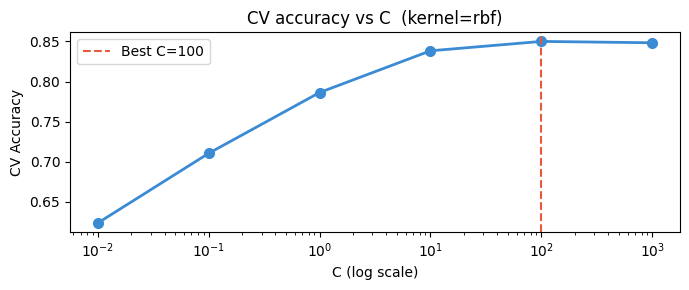

In [19]:
# Tuning C for the best kernel

C_values = [0.01, 0.1, 1, 10, 100, 1000]
c_scores = []

print(f'Tuning C for kernel={best_kernel}:')
print(f"{'C':>8} {'CV Accuracy':>12} {'Std':>8}")
print('-' * 32)
for C in C_values:
    svm = SVC(kernel=best_kernel, C=C, class_weight='balanced', random_state=42)
    scores = cross_val_score(svm, X_train_sm, y_train_sm,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    c_scores.append(scores.mean())
    print(f'{C:>8} {scores.mean():>12.4f} {scores.std():>8.4f}')

best_C = C_values[np.argmax(c_scores)]
print(f'\nBest C: {best_C}  (CV acc={max(c_scores):.4f})')

plt.figure(figsize=(7, 3))
plt.semilogx(C_values, c_scores, marker='o', color='#3B8BD4', linewidth=2, markersize=7)
plt.axvline(best_C, linestyle='--', color='#E8593C', linewidth=1.5, label=f'Best C={best_C}')
plt.title(f'CV accuracy vs C  (kernel={best_kernel})')
plt.xlabel('C (log scale)'); plt.ylabel('CV Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
svm_final = SVC(
    kernel=best_kernel,        # selected by CV kernel comparison
    C=best_C,                  # regularisation tuned by CV
    class_weight='balanced',   # compensates for class imbalance
    probability=False,         # not needed for class prediction
    random_state=42
)
svm_final.fit(X_train_sm, y_train_sm)
y_pred_sm = svm_final.predict(X_test)
print(f'SVM trained: kernel={best_kernel}, C={best_C}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred_sm):.4f}')

SVM trained: kernel=rbf, C=100
Test accuracy: 0.6949


In [21]:
# Train without SMOTE using same hyperparameters
svm_no_smote = SVC(
    kernel=best_kernel,
    C=best_C,
    class_weight='balanced',
    random_state=42
)
svm_no_smote.fit(X_train, y_train)   # original imbalanced training set
y_pred_no = svm_no_smote.predict(X_test)

# Metrics table
def metrics(y_true, y_pred):
    return {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'F1 macro':    f1_score(y_true, y_pred, average='macro'),
        'F1 weighted': f1_score(y_true, y_pred, average='weighted'),
    }

m_no = metrics(y_test, y_pred_no)
m_sm = metrics(y_test, y_pred_sm)

print('=' * 52)
print('    SVM — WITH vs WITHOUT SMOTE COMPARISON')
print('=' * 52)
print(f"{'Metric':<18} {'No SMOTE':>12} {'+ SMOTE':>12} {'Change':>8}")
print('-' * 52)
for key in m_no:
    diff = m_sm[key] - m_no[key]
    print(f'{key:<18} {m_no[key]:>12.4f} {m_sm[key]:>12.4f} {diff:>+8.4f}')
print('=' * 52)


    SVM — WITH vs WITHOUT SMOTE COMPARISON
Metric                 No SMOTE      + SMOTE   Change
----------------------------------------------------
Accuracy                 0.6915       0.6949  +0.0034
F1 macro                 0.6366       0.6350  -0.0016
F1 weighted              0.6975       0.6982  +0.0008


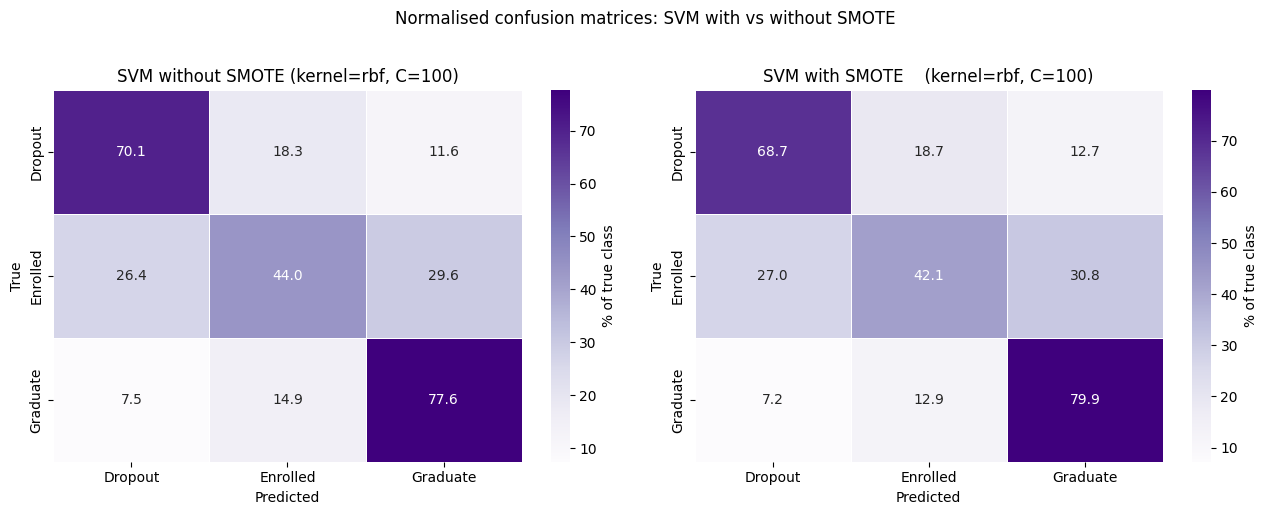

In [22]:
# Side-by-side normalised confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(
    axes,
    [y_pred_no, y_pred_sm],
    [f'SVM without SMOTE (kernel={best_kernel}, C={best_C})',
     f'SVM with SMOTE    (kernel={best_kernel}, C={best_C})']
):
    cm = confusion_matrix(y_test, pred).astype(float)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': '% of true class'}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Normalised confusion matrices: SVM with vs without SMOTE', y=1.02)
plt.tight_layout(); plt.show()

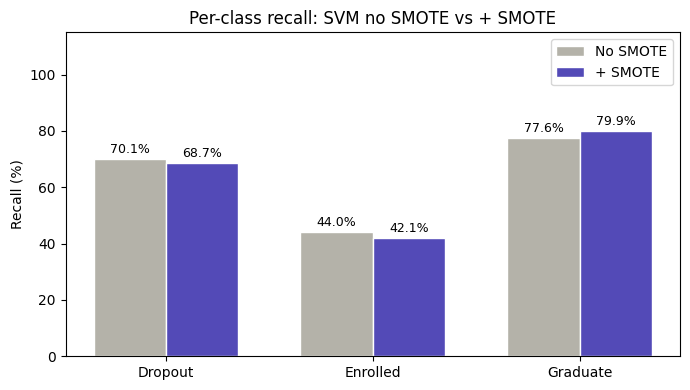

--- SVM without SMOTE ---
              precision    recall  f1-score   support

     Dropout       0.73      0.70      0.71       284
    Enrolled       0.37      0.44      0.40       159
    Graduate       0.81      0.78      0.79       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.69      0.70       885

--- SVM with SMOTE ---
              precision    recall  f1-score   support

     Dropout       0.72      0.69      0.70       284
    Enrolled       0.38      0.42      0.40       159
    Graduate       0.81      0.80      0.80       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.69      0.70       885



In [23]:
# Per-class recall bar chart
cm_no = confusion_matrix(y_test, y_pred_no)
cm_sm = confusion_matrix(y_test, y_pred_sm)
recalls_no = [cm_no[i,i]/cm_no[i].sum()*100 for i in range(3)]
recalls_sm = [cm_sm[i,i]/cm_sm[i].sum()*100 for i in range(3)]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, recalls_no, w, label='No SMOTE', color='#B4B2A9', edgecolor='white')
b2 = ax.bar(x + w/2, recalls_sm, w, label='+ SMOTE',  color='#534AB7', edgecolor='white')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(le.classes_)
ax.set_ylabel('Recall (%)'); ax.set_ylim(0, 115)
ax.set_title('Per-class recall: SVM no SMOTE vs + SMOTE')
ax.legend(); plt.tight_layout(); plt.show()

# Full classification reports
print('--- SVM without SMOTE ---')
print(classification_report(y_test, y_pred_no, target_names=le.classes_))
print('--- SVM with SMOTE ---')
print(classification_report(y_test, y_pred_sm, target_names=le.classes_))

In [24]:
best_pred = y_pred_sm if m_sm['F1 macro'] >= m_no['F1 macro'] else y_pred_no
best_label = '+ SMOTE' if m_sm['F1 macro'] >= m_no['F1 macro'] else 'No SMOTE'

print('=' * 52)
print('         SVM FINAL RESULTS SUMMARY')
print('=' * 52)
print(f'  Kernel:             {best_kernel}')
print(f'  Best C:             {best_C}')
print(f'  class_weight:       balanced')
print(f'  Best configuration: {best_label}')
print(f'  Dataset size:       {X.shape[0]} students')
print(f'  Features used:      {X_sel.shape[1]}')
print(f'  Train/test split:   80% / 20% (stratified)')
print('-' * 52)
print(f'  Test accuracy:      {accuracy_score(y_test, best_pred):.4f}')
print(f'  F1 (macro):         {f1_score(y_test, best_pred, average="macro"):.4f}')
print(f'  F1 (weighted):      {f1_score(y_test, best_pred, average="weighted"):.4f}')
print('=' * 52)

         SVM FINAL RESULTS SUMMARY
  Kernel:             rbf
  Best C:             100
  class_weight:       balanced
  Best configuration: No SMOTE
  Dataset size:       4424 students
  Features used:      36
  Train/test split:   80% / 20% (stratified)
----------------------------------------------------
  Test accuracy:      0.6915
  F1 (macro):         0.6366
  F1 (weighted):      0.6975


In [28]:
# Download Model

import pickle
import os
from google.colab import files

os.makedirs('saved_models', exist_ok=True)

svm_bundle = {
    'model':    svm_final,
    'scaler':   scaler,
    'imputer':  imputer,
    'selector': sel,
    'encoder':  le,
}
with open('saved_models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_bundle, f)
print("svm model saved -> saved_models/svm_model.pkl")

files.download('saved_models/svm_model.pkl')

svm model saved -> saved_models/svm_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>